**D2l.ai Chapter 3**

**Linear Regression**

In [ ]:
%matplotlib inline
import math
import time
import numpy as np
import torch

Vectorization

In [7]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)
c = torch.zeros(n)
t = time.time()
for i in range(n):
    c[i] = a[i] + b[i]
f'{time.time() - t:.5f} sec'

'0.04652 sec'

In [8]:
t = time.time()
d = a + b
f'{time.time() - t:.5f} sec'

'0.00009 sec'

**Object-Oriented Design**

In [1]:
import time
import numpy as np
import torch
from torch import nn

### `HyperParameters` — auto-save constructor arguments

A utility mixin that removes boilerplate. Instead of writing `self.a = a; self.b = b; ...` for every argument, a subclass just calls `self.save_hyperparameters()` and all of `__init__`'s arguments become attributes automatically.

- `inspect.currentframe().f_back` — steps back into the calling `__init__` to read its local variables.
- `getargvalues(frame)` — grabs those locals as a dict, e.g. `{'self':..., 'a':1, 'b':2, 'c':3}`.
- The comprehension keeps everything except `self` and anything in `ignore`.
- `setattr(self, k, v)` — the dynamic form of `self.k = v`, which actually creates the attributes.

In the demo, `ignore=['c']` means `c` is **not** saved, so `hasattr(self, 'c')` is `False`.

In [2]:
import inspect

class HyperParameters:
    def save_hyperparameters(self, ignore=[]):
        frame = inspect.currentframe().f_back
        _, _, _, local_vars = inspect.getargvalues(frame)
        self.hparams = {k: v for k, v in local_vars.items()
                        if k not in set(ignore + ['self'])}
        for k, v in self.hparams.items():
            setattr(self, k, v)

class B(HyperParameters):
    def __init__(self, a, b, c):
        self.save_hyperparameters(ignore=['c'])
        print('self.a =', self.a, 'self.b =', self.b)
        print('There is no self.c =', not hasattr(self, 'c'))

b = B(a=1, b=2, c=3)


self.a = 1 self.b = 2
There is no self.c = True


### `ProgressBoard` — live training plot

Accumulates `(x, y)` points per curve and redraws them, so you can watch metrics (like loss) update in real time during training.

- `self.data` maps each label to two parallel lists: `{'sin': ([x...], [y...]), ...}`.
- `every_n` is a performance throttle: every point is **stored**, but the (expensive) redraw only happens every `n`-th point — `if len(...) % every_n != 0: return` skips drawing otherwise.
- `display.display(...)` + `display.clear_output(wait=True)` is the Jupyter animation trick: draw the new figure, then clear the old one, giving the illusion of a single updating plot instead of many stacked plots.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

class ProgressBoard:
    def __init__(self, xlabel=None, ylabel=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 ls=['-', '--', '-.', ':'], colors=['C0','C1','C2','C3'],
                 fig=None, axes=None, figsize=(3.5, 2.5), display=True):
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.xlim = xlim
        self.ylim = ylim
        self.xscale = xscale
        self.yscale = yscale
        self.ls = ls
        self.colors = colors
        self.figsize = figsize
        self.display = display
        self.data = {}

    def draw(self, x, y, label, every_n=1):
        if label not in self.data:
            self.data[label] = ([], [])
        self.data[label][0].append(x)
        self.data[label][1].append(y)
        if len(self.data[label][0]) % every_n != 0:
            return
        plt.clf()
        for i, (lbl, (xs, ys)) in enumerate(self.data.items()):
            plt.plot(xs, ys, self.ls[i % len(self.ls)], label=lbl)
        if self.xlabel: plt.xlabel(self.xlabel)
        if self.ylabel: plt.ylabel(self.ylabel)
        plt.legend()
        display.display(plt.gcf())
        display.clear_output(wait=True)


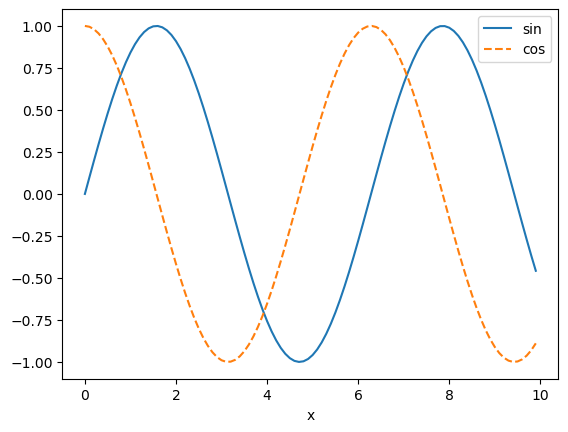

In [4]:
board = ProgressBoard('x')
for x in np.arange(0, 10, 0.1):
    board.draw(x, np.sin(x), 'sin', every_n=2)
    board.draw(x, np.cos(x), 'cos', every_n=10)

Models

### `Module` — base class for all models

Inherits from both `nn.Module` (PyTorch's base for anything with learnable weights — gives autograd, `.parameters()`, GPU moves) **and** `HyperParameters` (the auto-save mixin).

- `super().__init__()` — calls `nn.Module.__init__()`, which is **mandatory** for PyTorch's internal bookkeeping. Every model also gets its own `ProgressBoard`.
- `forward(X)` — the **prediction**. PyTorch calls this when you do `model(X)`. The default runs `self.net(X)`; the `assert` warns if a subclass forgot to define `self.net`.
- `loss(y_hat, y)` — a **stub** (`raise NotImplementedError`): every subclass MUST define how to measure error (squared error, cross-entropy, etc.).
- `training_step(batch)` — processes one batch: `batch[:-1]` is the inputs, `batch[-1]` the labels. It runs `forward`, computes the loss, plots it, and returns the loss so the trainer can backprop.
- `validation_step` — same but no return value (validation only measures; it doesn't update weights).
- `plot(...)` — computes the x-position (fractional epoch) and sends the loss value to the board. Note `.detach().cpu().numpy()`: strip the gradient graph, move to CPU, convert to numpy for matplotlib.
- `configure_optimizers` — another stub: the subclass picks the optimizer (SGD, Adam, ...).

In [5]:
class Module(nn.Module, HyperParameters):  #@save
    """The base class of models."""
    def __init__(self, plot_train_per_epoch=2, plot_valid_per_epoch=1):
        super().__init__()
        self.save_hyperparameters()
        self.board = ProgressBoard()

    def loss(self, y_hat, y):
        raise NotImplementedError

    def forward(self, X):
        assert hasattr(self, 'net'), 'Neural network is defined'
        return self.net(X)

    def plot(self, key, value, train):
        """Plot a point in animation."""
        assert hasattr(self, 'trainer'), 'Trainer is not inited'
        self.board.xlabel = 'epoch'
        if train:
            x = self.trainer.train_batch_idx / \
                self.trainer.num_train_batches
            n = self.trainer.num_train_batches / \
                self.plot_train_per_epoch
        else:
            x = self.trainer.epoch + 1
            n = self.trainer.num_val_batches / \
                self.plot_valid_per_epoch
        self.board.draw(x, value.detach().cpu().numpy(),
                ('train_' if train else 'val_') + key,
                every_n=int(n))


    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=True)
        return l

    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=False)

    def configure_optimizers(self):
        raise NotImplementedError

Data

### `DataModule` — base class for data

Defines the interface for feeding data to a model. A **dataloader** is an object that yields batches one at a time.

- `get_dataloader(train)` — the one real method a subclass must implement: return training data when `train=True`, validation data otherwise.
- `train_dataloader()` / `val_dataloader()` — convenience wrappers so the trainer can call clearly-named methods.

This is the **template method pattern**: the base class fixes *what* methods exist; subclasses fill in *how*.

In [6]:
class DataModule(HyperParameters):  #@save
    """The base class of data."""
    def __init__(self, root='../data', num_workers=4):
        self.save_hyperparameters()

    def get_dataloader(self, train):
        raise NotImplementedError

    def train_dataloader(self):
        return self.get_dataloader(train=True)

    def val_dataloader(self):
        return self.get_dataloader(train=False)

Training

### `Trainer` — the orchestrator

The conductor that connects a model and its data and runs the training loop.

- `prepare_data(data)` — grabs the train/val dataloaders and counts their batches (needed for the plot's x-axis).
- `prepare_model(model)` — sets `model.trainer = self`, a **two-way link** so the model's `plot` can read `self.trainer.epoch` etc.
- `fit(model, data)` — ties it all together: prepare data, prepare model, ask the model for its optimizer, then loop `fit_epoch()` once per epoch (an **epoch** = one full pass over the training data).
- `fit_epoch()` — a stub here; the actual per-batch logic (forward, backprop, weight update) is filled in by a subclass below.

In [7]:
class Trainer(HyperParameters):  #@save
    """The base class for training models with data."""
    def __init__(self, max_epochs, num_gpus=0, gradient_clip_val=0):
        self.save_hyperparameters()
        assert num_gpus == 0, 'No GPU support yet'

    def prepare_data(self, data):
        self.train_dataloader = data.train_dataloader()
        self.val_dataloader = data.val_dataloader()
        self.num_train_batches = len(self.train_dataloader)
        self.num_val_batches = (len(self.val_dataloader)
                                if self.val_dataloader is not None else 0)

    def prepare_model(self, model):
        model.trainer = self
        model.board.xlim = [0, self.max_epochs]
        self.model = model

    def fit(self, model, data):
        self.prepare_data(data)
        self.prepare_model(model)
        self.optim = model.configure_optimizers()
        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()

    def fit_epoch(self):
        raise NotImplementedError

## Putting it together — end-to-end workflow

The cell below subclasses the three base classes to actually do **linear regression**, then runs training. Here's the full flow.

**Setup**
1. `SyntheticRegressionData(...)` — generates 2000 fake rows where `y = Xw + b + noise`. These are the "correct answers" the model must rediscover.
2. `LinearRegression(num_inputs=2, lr=0.03)` — creates `self.net = nn.Linear(2, 1)` (2 weights + 1 bias, **randomly initialized** — the model knows nothing yet).
3. `Trainer(max_epochs=5)` — will run 5 passes over the data.

**`trainer.fit(model, data)` — orchestration**
- `prepare_data` → grabs the train/val `DataLoader`s and counts batches.
- `prepare_model` → links model and trainer together.
- `configure_optimizers` → model returns `SGD(self.parameters(), lr=0.03)`. `self.parameters()` (from `nn.Module`) automatically finds the weights inside `self.net`.
- loops `fit_epoch()` 5 times.

**Inside `fit_epoch` — the actual learning (per batch of 32 rows):**
1. `training_step(batch)` → `forward(X)` makes predictions → `loss(y_hat, y)` measures error → returns one scalar loss.
2. `optim.zero_grad()` → clear gradients from the previous batch (PyTorch accumulates them, so this reset is required).
3. `loss.backward()` → autograd computes `d(loss)/d(weight)` for every weight.
4. `optim.step()` → SGD nudges each weight a small step (`lr`) in the direction that lowers the loss.

After all batches, the validation loop runs `validation_step` (measuring only — no weight updates). Repeat for 5 epochs.

**Result:** the estimated `w` and `b` converge to the true `[2.0, -3.4]` and `4.2` — the model has *learned* the hidden parameters from noisy data.

**Why the design pays off:** to make linear regression work you only wrote `get_dataloader`, `forward`/`loss`/`configure_optimizers`, and `fit_epoch`. Everything else — orchestration, plotting, train/val split, hyperparameter saving — came for free from the base classes. The next chapter reuses `Trainer` and `DataModule` unchanged and only swaps the model.

Estimated w: tensor([[ 2.0002, -3.3997]])
Estimated b: tensor([4.1988])


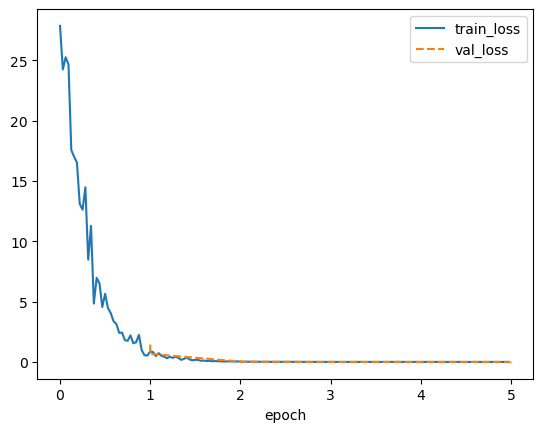

In [8]:
import torch
from torch import nn

# ============================================================
# 1. DATA: generate synthetic data y = 2*x1 - 3.4*x2 + 4.2 + noise
# ============================================================
class SyntheticRegressionData(DataModule):
    def __init__(self, w, b, noise=0.01, num_train=1000, num_val=1000,
                 batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, len(w))              # random inputs
        noise = torch.randn(n, 1) * noise
        self.y = self.X @ w.reshape(-1, 1) + b + noise  # true labels

    def get_dataloader(self, train):
        if train:
            indices = slice(0, self.num_train)
        else:
            indices = slice(self.num_train, self.num_train + self.num_val)
        dataset = torch.utils.data.TensorDataset(self.X[indices], self.y[indices])
        return torch.utils.data.DataLoader(
            dataset, self.batch_size, shuffle=train)


# ============================================================
# 2. MODEL: linear regression
# ============================================================
class LinearRegression(Module):
    def __init__(self, num_inputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Linear(num_inputs, 1)   # the actual weights & bias

    def forward(self, X):
        return self.net(X)                    # prediction = Xw + b

    def loss(self, y_hat, y):
        fn = nn.MSELoss()                     # mean squared error
        return fn(y_hat, y)

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)

# ============================================================
# 3. TRAINER: fill in the actual training loop
# ============================================================
class Trainer(Trainer):   # extend the base Trainer with fit_epoch
    def fit_epoch(self):
        self.model.train()                    # set model to training mode
        for batch in self.train_dataloader:
            loss = self.model.training_step(batch)
            self.optim.zero_grad()            # clear old gradients
            with torch.no_grad():
                loss.backward()               # compute gradients
                self.optim.step()             # update weights
            self.train_batch_idx += 1
        self.model.eval()                     # set model to eval mode
        for batch in self.val_dataloader:
            with torch.no_grad():
                self.model.validation_step(batch)
            self.val_batch_idx += 1

# ============================================================
# 4. RUN IT
# ============================================================
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
data = SyntheticRegressionData(w=true_w, b=true_b)
model = LinearRegression(num_inputs=2, lr=0.03)
trainer = Trainer(max_epochs=5)
trainer.fit(model, data)

print('Estimated w:', model.net.weight.data)
print('Estimated b:', model.net.bias.data)


**Synthetic Regression Data**

In [9]:
%matplotlib inline
import random
import torch

In [10]:
class SyntheticRegressionData(DataModule):  #@save
    """Synthetic data for linear regression."""
    def __init__(self, w, b, noise=0.01, num_train=1000, num_val=1000,
                 batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, len(w))
        noise = torch.randn(n, 1) * noise
        self.y = torch.matmul(self.X, w.reshape((-1, 1))) + b + noise
    def get_dataloader(self, train):
        if train:
            indices = list(range(0, self.num_train))
         # The examples are read in random order
            random.shuffle(indices)
        else:
            indices = list(range(self.num_train, self.num_train+self.num_val))
        for i in range(0, len(indices), self.batch_size):
            batch_indices = torch.tensor(indices[i: i+self.batch_size])
            yield self.X[batch_indices], self.y[batch_indices]
    def get_tensorloader(self, tensors, train, indices=slice(0, None)):
        tensors = tuple(a[indices] for a in tensors)
        dataset = torch.utils.data.TensorDataset(*tensors)
        return torch.utils.data.DataLoader(dataset, self.batch_size, shuffle=train)
    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader((self.X, self.y), train, i)

In [11]:
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)

In [12]:
print('features:', data.X[0],'\nlabel:', data.y[0])

features: tensor([-2.6113, -1.6591]) 
label: tensor([4.6167])


In [13]:
X, y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\ny shape:', y.shape)

X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


In [14]:
X, y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\ny shape:', y.shape)

X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


In [15]:
len(data.train_dataloader())

32